## Importing libraries

In [1]:
from keras.models import Sequential, load_model
import tensorflow as tf
from keras.layers import Convolution2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import MaxPooling2D, Conv2D, MaxPool2D, Activation, GlobalAveragePooling2D, BatchNormalization, Dropout
from matplotlib import pyplot as plt
from keras.preprocessing.image import ImageDataGenerator

## Data pre-processing

In [2]:


train_datagen = ImageDataGenerator(rescale=1. / 255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

print("\nTraining the data...\n")
training_set = train_datagen.flow_from_directory('../cerivical data/train/',
                                                 target_size=(224,224),
                                                 batch_size=12,
                                                 class_mode='categorical'
                                                 )

test_set = train_datagen.flow_from_directory('../cerivical data/test',
                                            target_size=(224,224),
                                            batch_size=12,
                                            class_mode='categorical'
                                            )
print("\n Testing the data.....\n")




Training the data...

Found 1517 images belonging to 2 classes.
Found 694 images belonging to 2 classes.

 Testing the data.....



## CNN Model building

In [3]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='Same', activation='relu', input_shape=(224,224, 3)))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=96, kernel_size=(3,3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=96, kernel_size=(3,3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dense(2, activation="softmax"))

model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


history=model.fit(training_set,epochs = 30,validation_data = test_set,verbose = 1)

model.save(r"models/CNN.h5")




Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 224, 224, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 112, 112, 32)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 112, 112, 64)      18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 56, 56, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 56, 56, 96)        55392     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 28, 28, 96)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 28, 28, 96)        8

## Plotting graphs

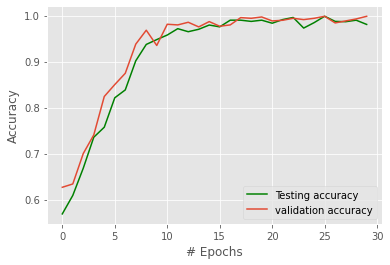

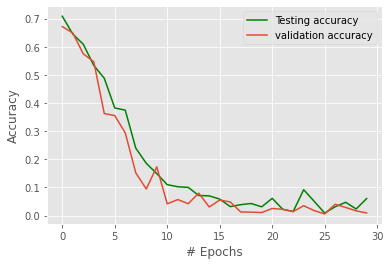

0.9808833003044128


In [4]:

plt.style.use("ggplot")
plt.figure()
plt.plot(history.history['accuracy'],'r',label='Testing accuracy',color='green')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.xlabel('# Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("models/CNN_acc.png")
plt.show()


plt.style.use("ggplot")
plt.figure()
plt.plot(history.history['loss'],'r',label='Testing accuracy',color='green')
plt.plot(history.history['val_loss'],label='validation accuracy')
plt.xlabel('# Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("models/CNN_loss.png")
plt.show()


acc=history.history['accuracy'][-1]
print(acc)



## Mobilenet model building

In [5]:
base_model = tf.keras.applications.MobileNet(input_shape=(224,224, 3), include_top=False,
                          weights='imagenet')
model1 = Sequential()
model1.add(base_model)
model1.add(GlobalAveragePooling2D())
model1.add(Dense(64, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.2))
model1.add(Dense(2, activation='sigmoid'))
model1.summary()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


history=model.fit_generator(training_set,epochs = 30,validation_data = test_set,verbose = 1)

model.save("models/mobilenet.h5")


Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
mobilenet_1.00_224 (Function (None, 7, 7, 1024)        3228864   
_________________________________________________________________
global_average_pooling2d (Gl (None, 1024)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 64)                65600     
_________________________________________________________________
batch_normalization (BatchNo (None, 64)                256       
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 2)                 130       
Total params: 3,294,850
Trainable params: 3,272,834
Non-trainable params: 22,016
_______________________________________

c:\Program Files\Python36\lib\site-packages\keras\engine\training.py:1972: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/30
127/127 [==============================] - 165s 1s/step - loss: 0.0548 - accuracy: 0.9848 - val_loss: 0.0187 - val_accuracy: 0.9971
Epoch 2/30
127/127 [==============================] - 166s 1s/step - loss: 0.0762 - accuracy: 0.9809 - val_loss: 0.0448 - val_accuracy: 0.9798
Epoch 3/30
127/127 [==============================] - 161s 1s/step - loss: 0.0227 - accuracy: 0.9914 - val_loss: 0.0374 - val_accuracy: 0.9870
Epoch 4/30
127/127 [==============================] - 162s 1s/step - loss: 0.0241 - accuracy: 0.9934 - val_loss: 0.0383 - val_accuracy: 0.9870
Epoch 5/30
127/127 [==============================] - 158s 1s/step - loss: 0.0047 - accuracy: 0.9980 - val_loss: 0.0043 - val_accuracy: 0.9986
Epoch 6/30
127/127 [==============================] - 158s 1s/step - loss: 0.0021 - accuracy: 0.9993 - val_loss: 6.7073e-04 - val_accuracy: 1.0000
Epoch 7/30
127/127 [==============================] - 156s 1s/step - loss: 0.0062 - accuracy: 0.9980 - val_loss: 0.0770 - val_accuracy: 0.

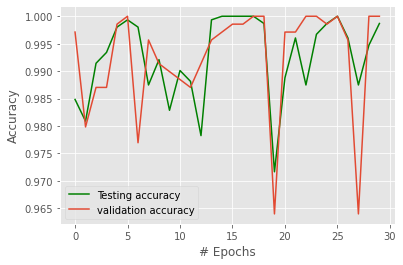

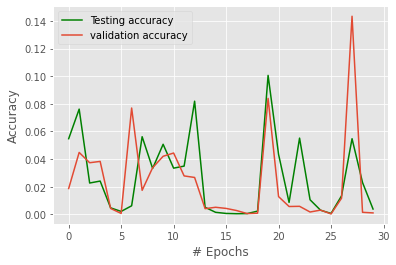

0.9986816048622131


In [6]:

plt.style.use("ggplot")
plt.figure()
plt.plot(history.history['accuracy'],'r',label='Testing accuracy',color='green')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.xlabel('# Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("models/mobilenet_acc.png")
plt.show()



plt.style.use("ggplot")
plt.figure()
plt.plot(history.history['loss'],'r',label='Testing accuracy',color='green')
plt.plot(history.history['val_loss'],label='validation accuracy')
plt.xlabel('# Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("models/mobilenet_loss.png")
plt.show()


acc=history.history['accuracy'][-1]
print(acc)

